In [1]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import os

load_dotenv()

PROCESSED_DIR = r"C:\Users\slast\OneDrive\Pulpit\geo_zadanie\01_data\procced"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

print("✅ Biblioteki załadowane")

c:\Users\slast\miniconda3\envs\GEO\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Biblioteki załadowane


In [2]:
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'features.csv'))

feature_cols = [c for c in df.columns 
                if c not in ['location_id', 'lat', 'lng', 'monthly_revenue']]

X = df[feature_cols]
y = df['monthly_revenue']

print(f"✅ Dataset: {df.shape[0]} lokalizacji × {len(feature_cols)} cech")
print(f"Feature columns: {feature_cols}")

✅ Dataset: 50 lokalizacji × 23 cech
Feature columns: ['signal_count', 'unique_users', 'peak_morning_signals', 'building_count', 'total_building_area', 'avg_building_area', 'residential_count', 'commercial_count', 'building_density', 'pop_total', 'pop_households', 'avg_hh_size', 'poi_bank', 'poi_bus_stop', 'poi_hospital', 'poi_mall', 'poi_park', 'poi_pharmacy', 'poi_restaurant', 'poi_school', 'poi_total', 'competitor_count', 'dist_nearest_competitor_m']


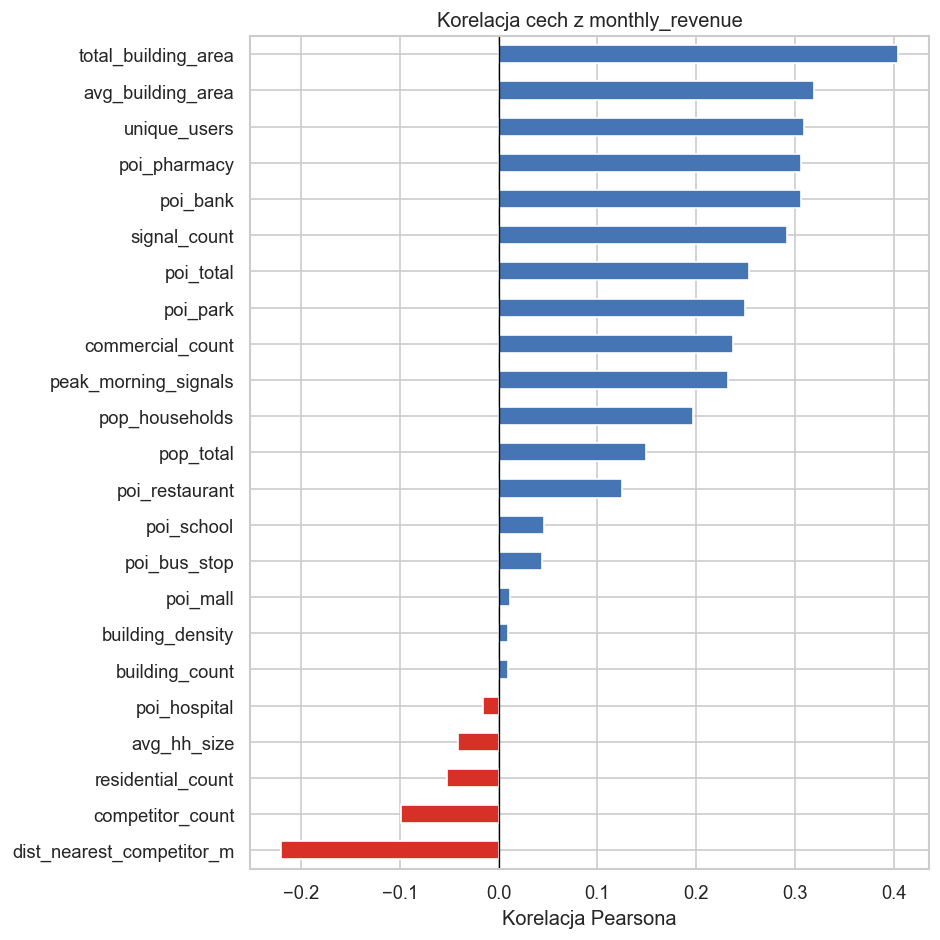

In [3]:
corr = df[feature_cols + ['monthly_revenue']].corr()['monthly_revenue'].drop('monthly_revenue')
corr_sorted = corr.sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#d73027' if v < 0 else '#4575b4' for v in corr_sorted.values]
corr_sorted.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelacja cech z monthly_revenue')
ax.set_xlabel('Korelacja Pearsona')
plt.tight_layout()
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:,.0f} PLN")

cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"CV R² (5-fold): {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

R²:   -0.505
RMSE: 122,908 PLN
CV R² (5-fold): -0.215 ± 0.332


In [5]:
model = xgb.XGBRegressor(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.5,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:,.0f} PLN")

cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"CV R² (5-fold): {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

R²:   -0.223
RMSE: 110,785 PLN
CV R² (5-fold): -0.186 ± 0.296


In [6]:
from sklearn.ensemble import RandomForestRegressor

# Tylko top 8 cech z korelacji
top_features = [
    'total_building_area', 'avg_building_area', 'unique_users',
    'signal_count', 'poi_pharmacy', 'poi_bank',
    'pop_households', 'dist_nearest_competitor_m'
]

X_top = df[top_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2   = r2_score(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:,.0f} PLN")

cv_r2 = cross_val_score(rf, X_top, y, cv=5, scoring='r2')
print(f"CV R² (5-fold): {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

R²:   -0.386
RMSE: 117,947 PLN
CV R² (5-fold): -0.038 ± 0.195


In [7]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10.0)

cv_r2 = cross_val_score(ridge, X_top, y, cv=5, scoring='r2')
print(f"Ridge CV R² (5-fold): {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42
)

ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

r2   = r2_score(y_test, y_pred_ridge)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:,.0f} PLN")

Ridge CV R² (5-fold): -0.129 ± 0.218
R²:   -0.168
RMSE: 108,278 PLN


In [8]:
# Trenujemy na całym zbiorze — do SHAP i whitespotu
model_full = xgb.XGBRegressor(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.5,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    verbosity=0
)

model_full.fit(X, y)
print("✅ Model wytrenowany na pełnym zbiorze")

✅ Model wytrenowany na pełnym zbiorze


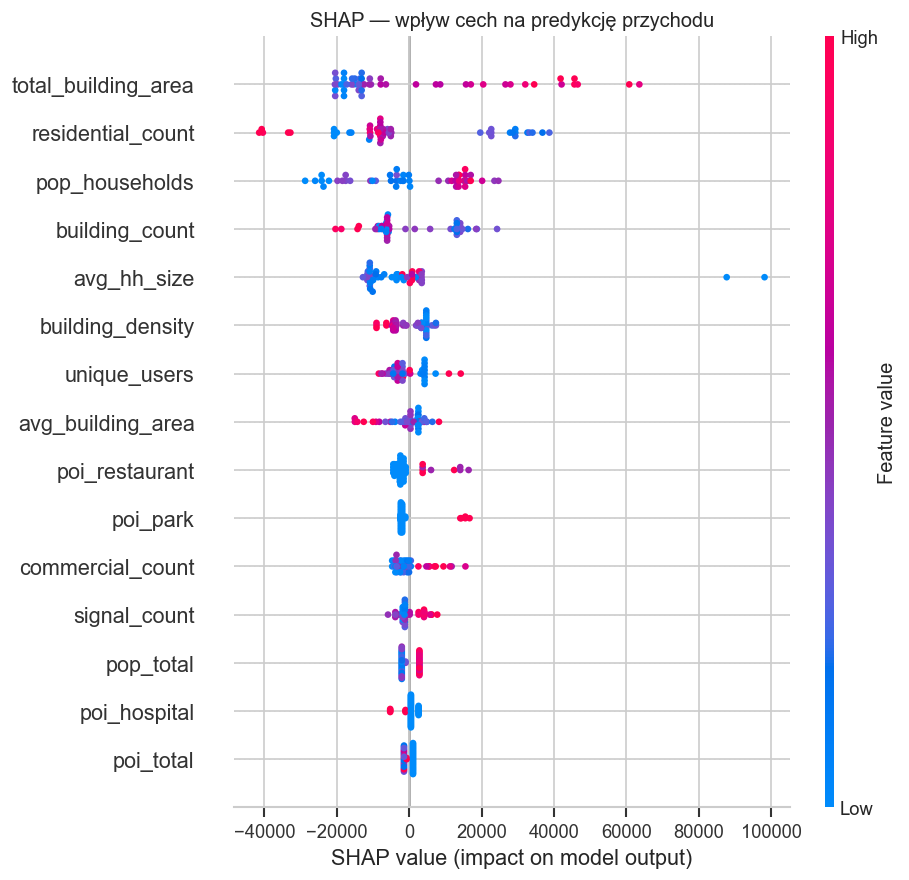

In [9]:
explainer = shap.TreeExplainer(model_full)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, show=False, max_display=15)
plt.title('SHAP — wpływ cech na predykcję przychodu')
plt.tight_layout()
plt.show()

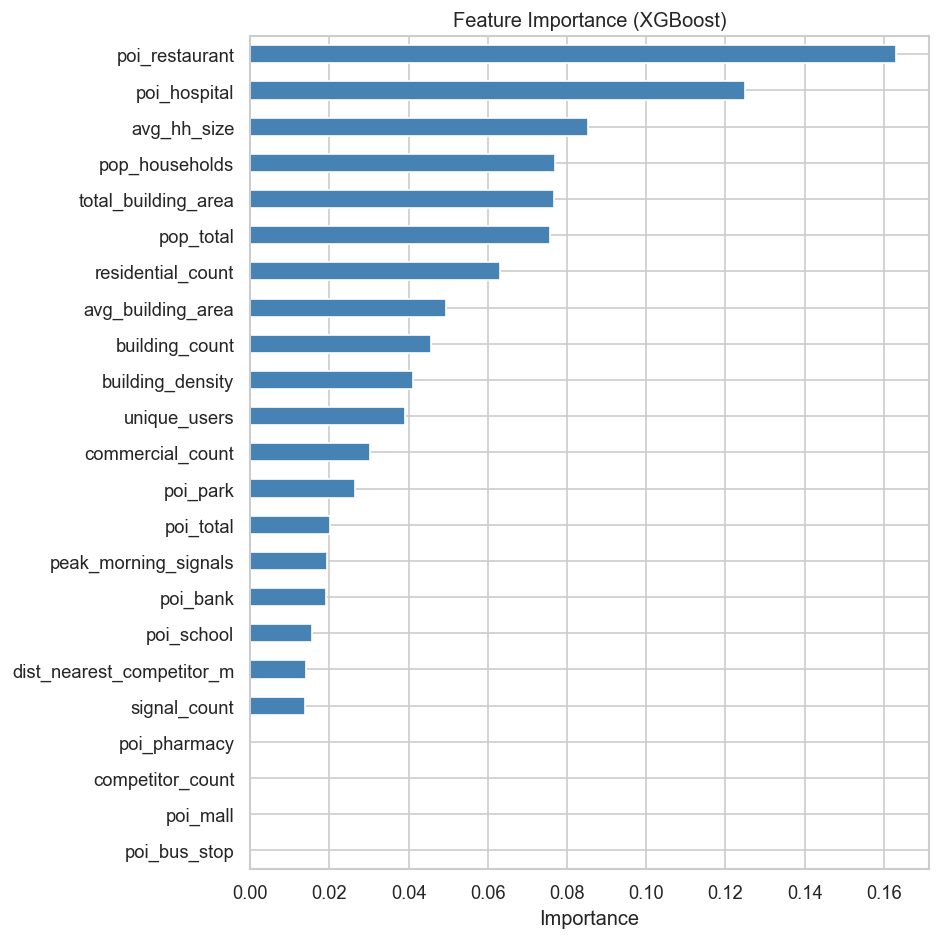

In [10]:
fi = pd.Series(model_full.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
fi.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance (XGBoost)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()